# Hotel Booking Cancellation - Exploratory Data Analysis (EDA)

This notebook explores the Hotel Booking Cancellation dataset to understand its structure, identify data quality issues, analyze feature distributions, and discover relationships that may help predict booking cancellations.

# Import Libraries

In [140]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns

plt.style.use('dark_background')
np.random.seed(42)
print("✅ Ready!")

✅ Ready!


# Load Dataset

In [141]:
df = pd.read_csv("../data/hotel_bookings.csv")
numeric_cols = df.select_dtypes(include=np.number).columns
print(f"Dataset: Hotel Booking Cancellation")
print(f"Samples: {len(df)}")
print(f"\nPreview:")
df.head()

Dataset: Hotel Booking Cancellation
Samples: 119390

Preview:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Dataset Overview

In [142]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 119390
Columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  me

# Statistical Summary

In [143]:
print("Statistical Summary:")
df.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


# Missing Values

In [144]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

company     112593
agent        16340
country        488
children         4
dtype: int64

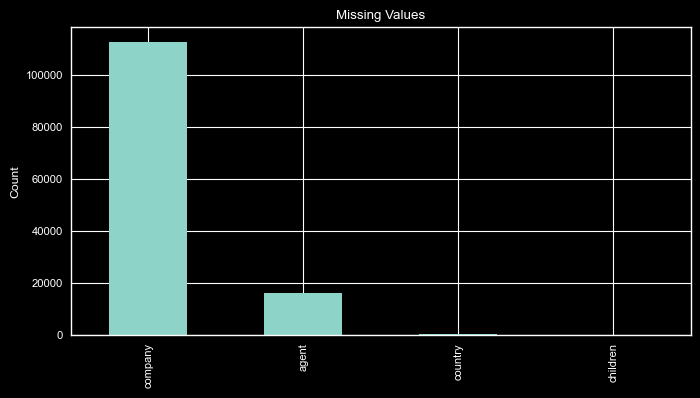

In [145]:
plt.figure(figsize=(8,4))

missing.plot(kind="bar")

plt.title("Missing Values")

plt.ylabel("Count")

plt.show()

# Duplicate Rows

In [146]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 31994


# Target Distribution

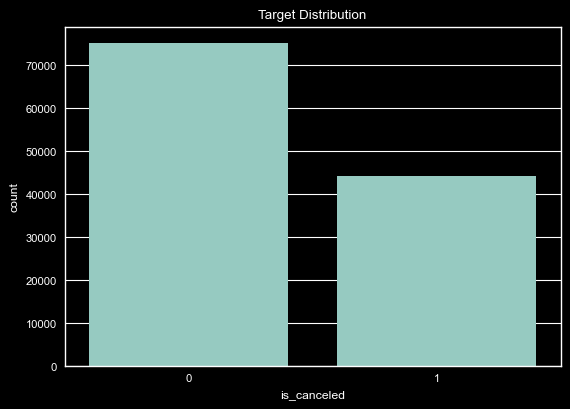

In [147]:
sns.countplot(
    data=df,
    x="is_canceled"
)

plt.title("Target Distribution")

plt.show()

In [148]:
df["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

## Numerical Features Distribution

In [149]:
numerical = df.select_dtypes(include=np.number).columns

len(numerical)

20

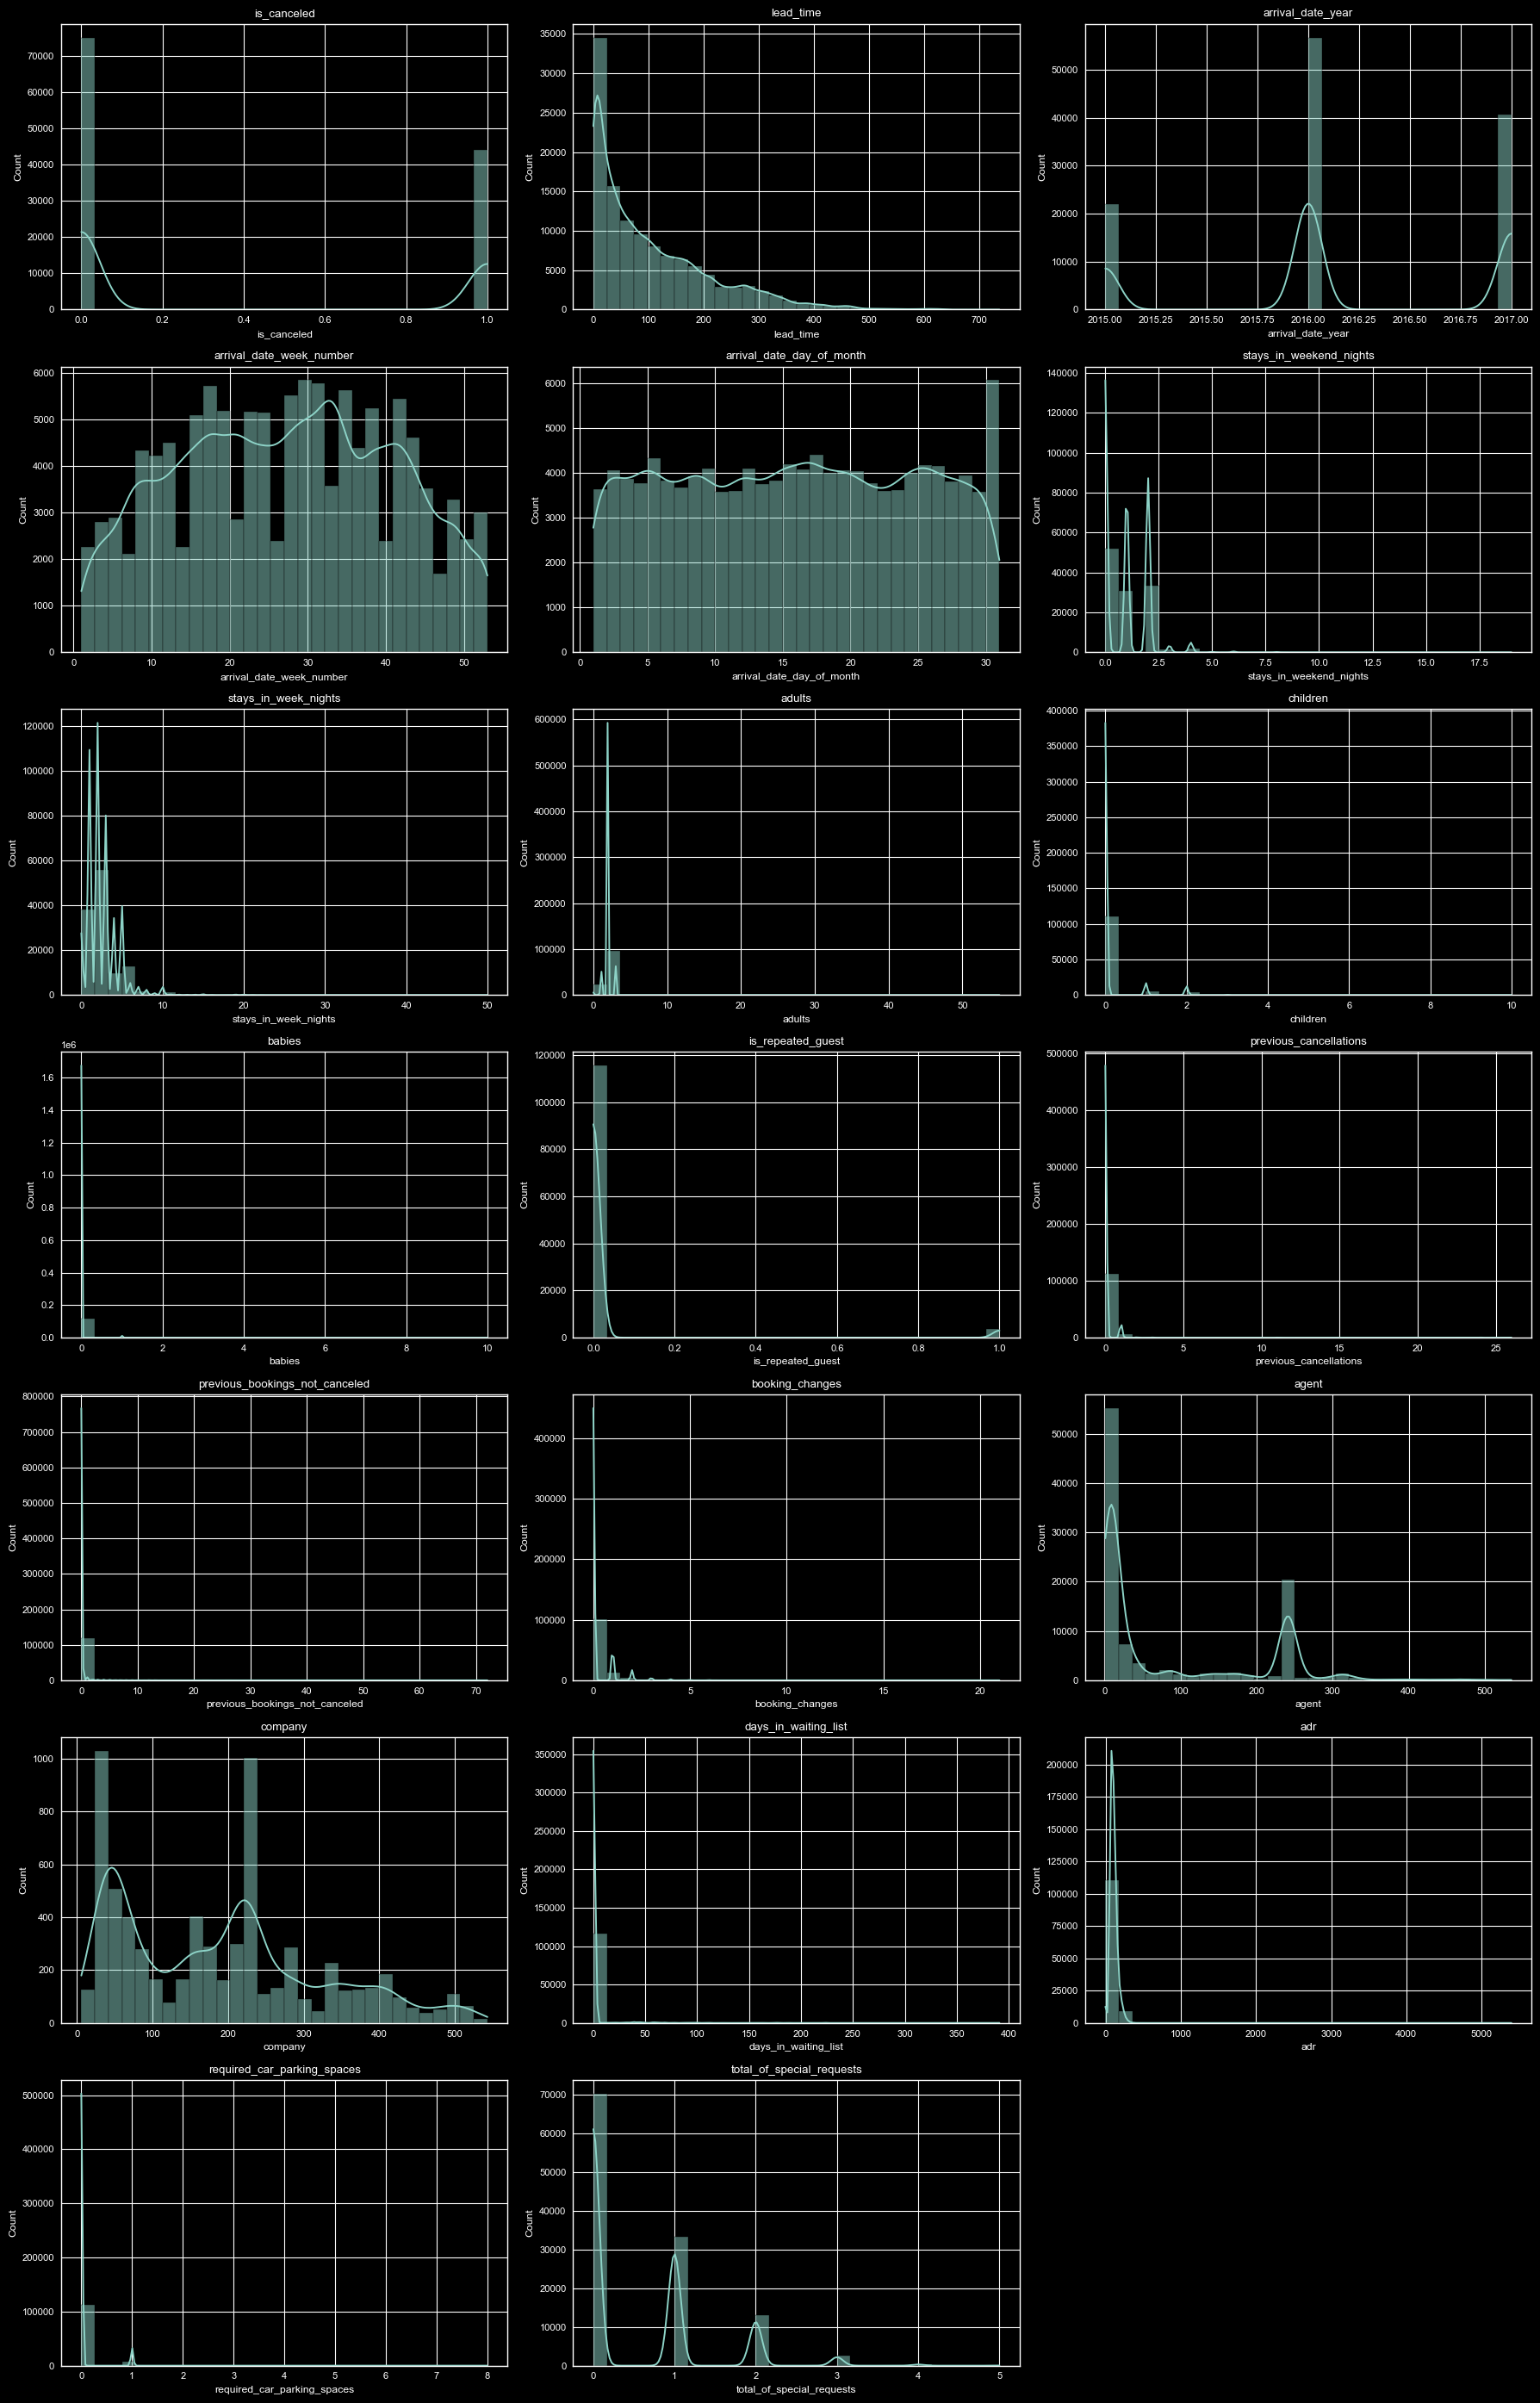

In [150]:
n_cols = 3
n_rows = math.ceil(len(numerical) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical):

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        edgecolor="black",
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(len(numerical), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Categorical Features

In [151]:
categorical = df.select_dtypes(exclude=np.number).columns

len(categorical)

12

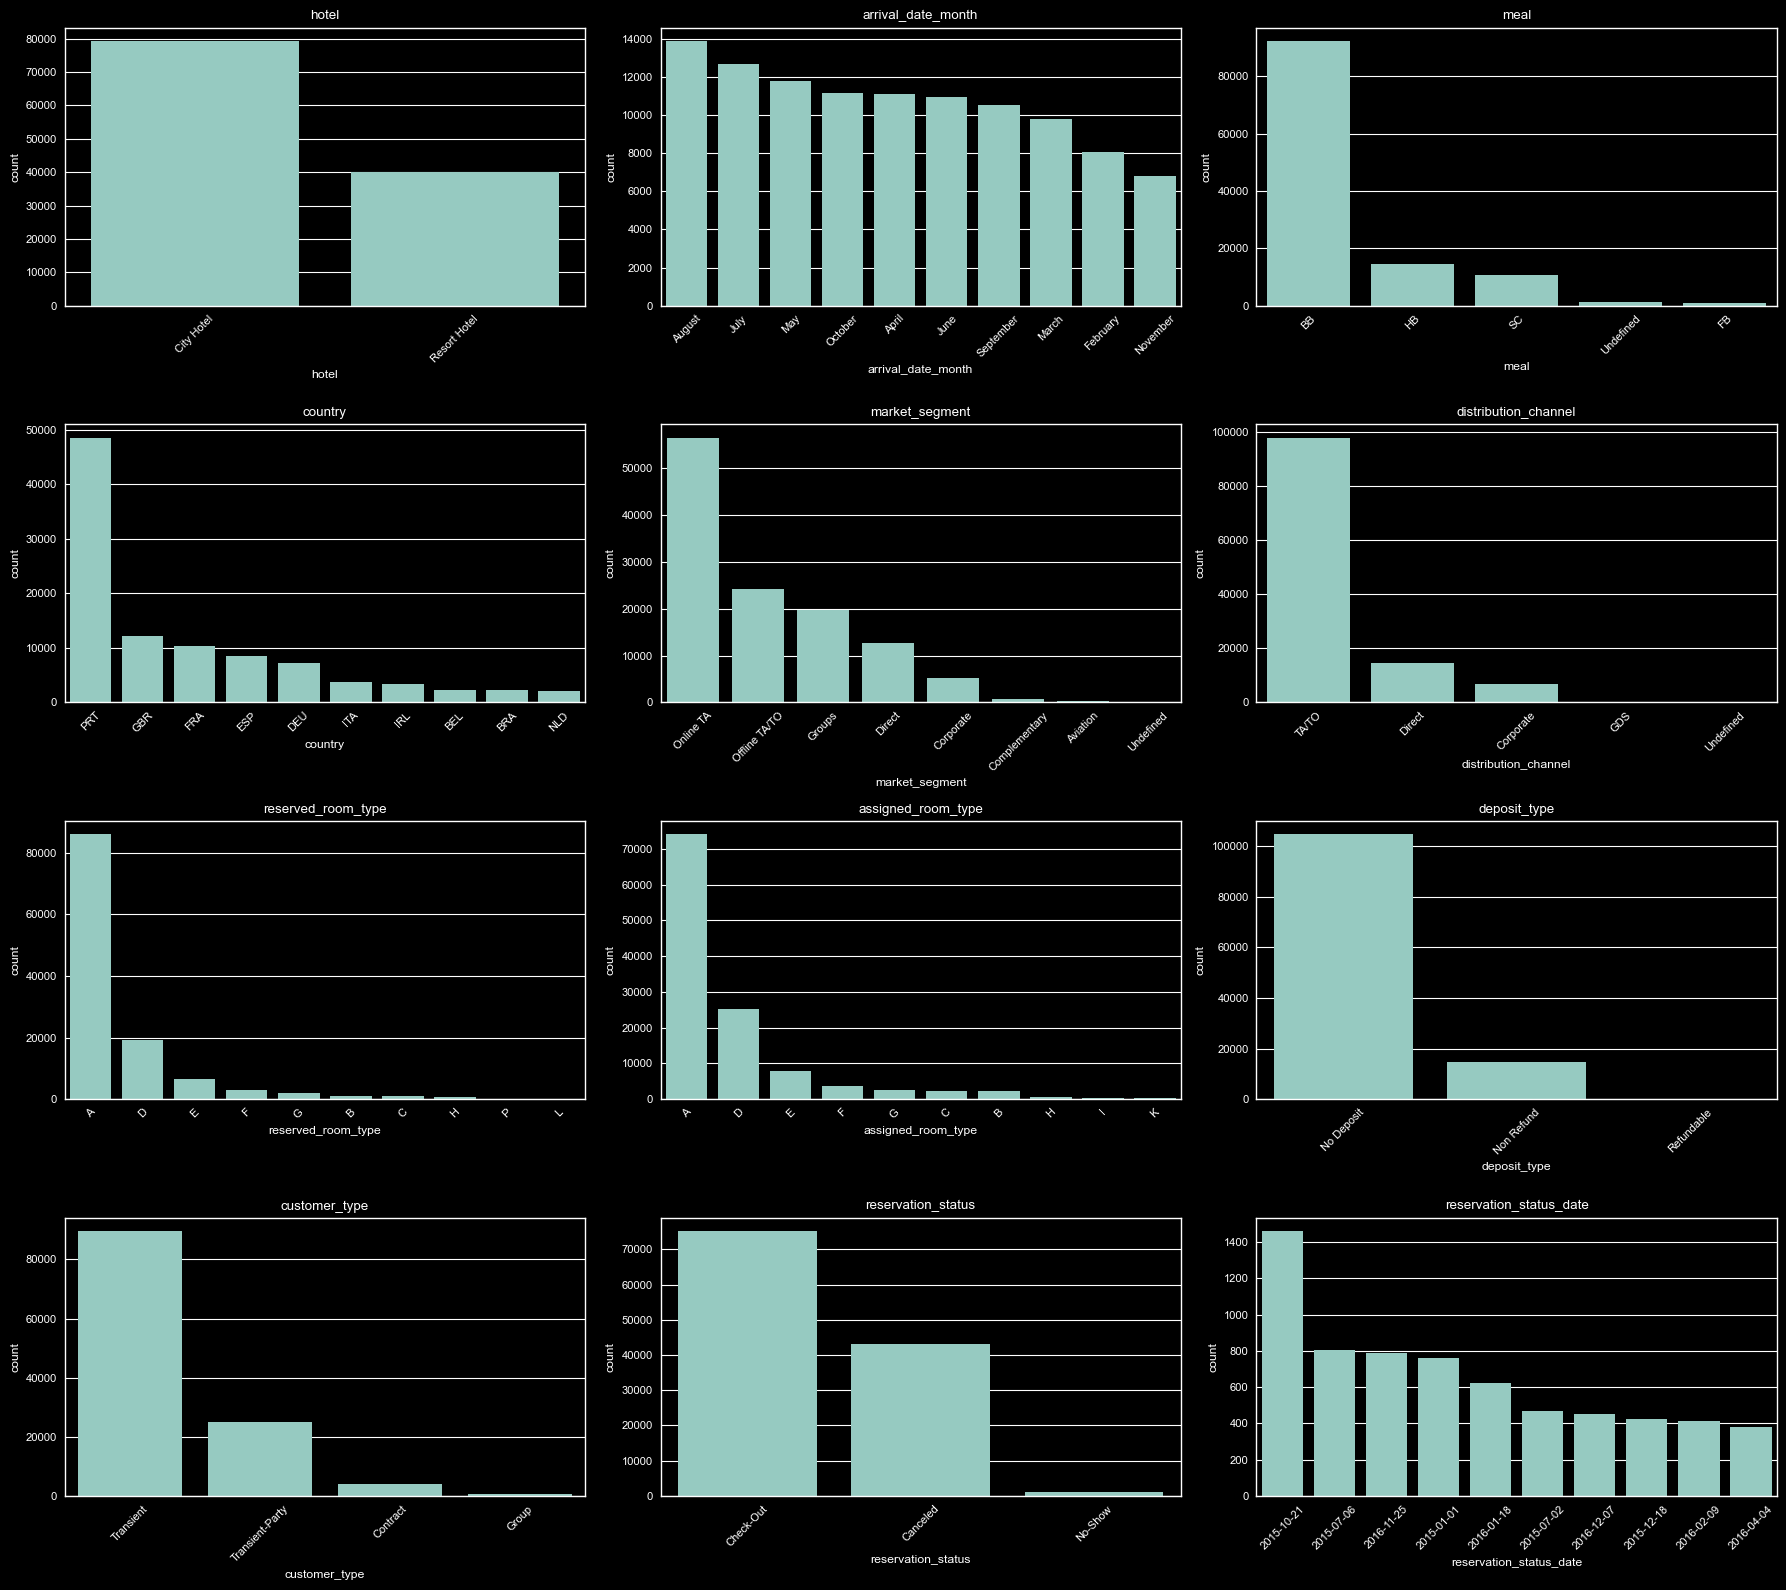

In [152]:
n_cols = 3
n_rows = math.ceil(len(categorical) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical):

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index[:10],
        ax=axes[i]    
    )
    axes[i].tick_params(
    axis="x",
    rotation=45
)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Correlation Heatmap

In [153]:
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

print("Correlation with Target (is_canceled):")
print(corr_matrix['is_canceled'].sort_values(ascending=False))

Correlation with Target (is_canceled):
is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
children                          0.005048
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
company                          -0.020642
babies                           -0.032491
previous_bookings_not_canceled   -0.057358
agent                            -0.083114
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64


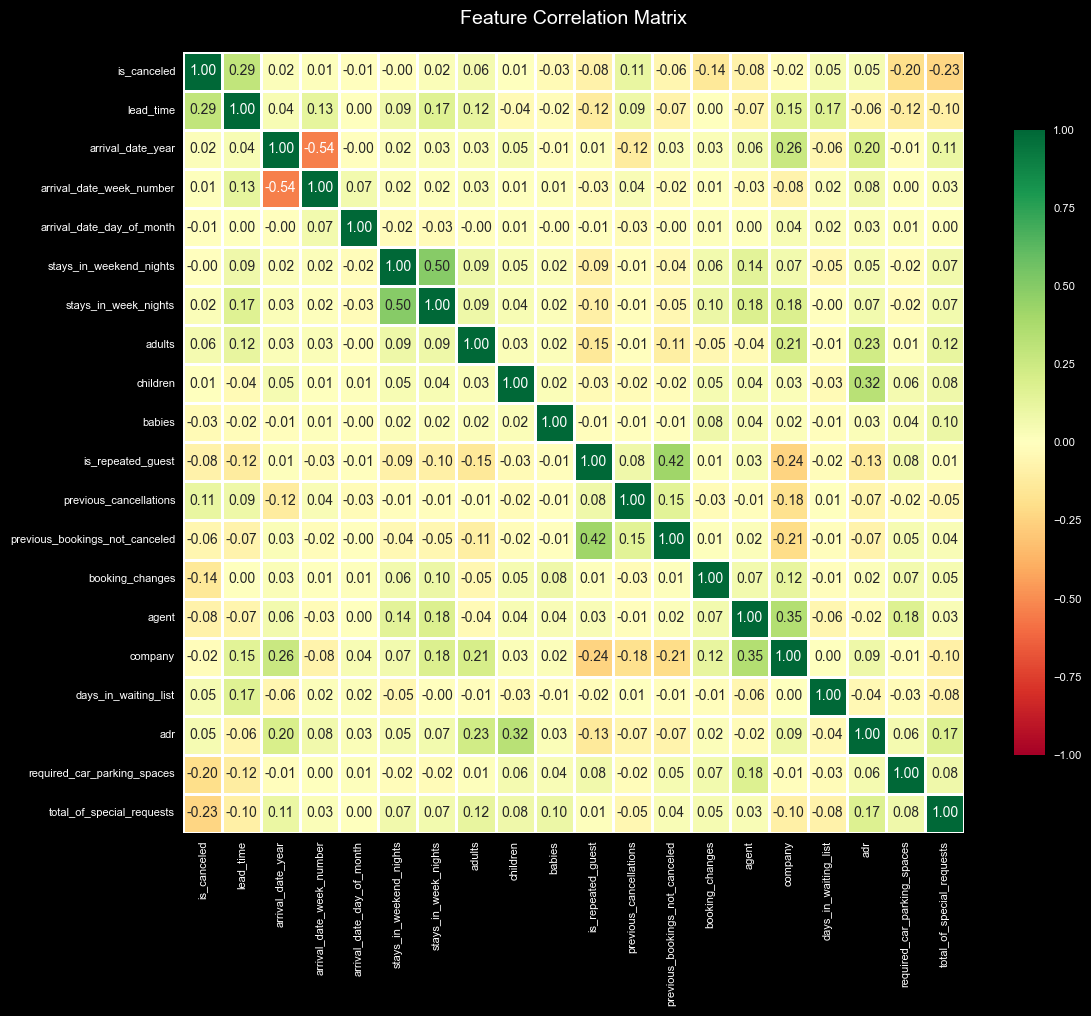

In [154]:
# Correlation heatmap .. note how the color reflects the value (use the colorbar on the right as the reference)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

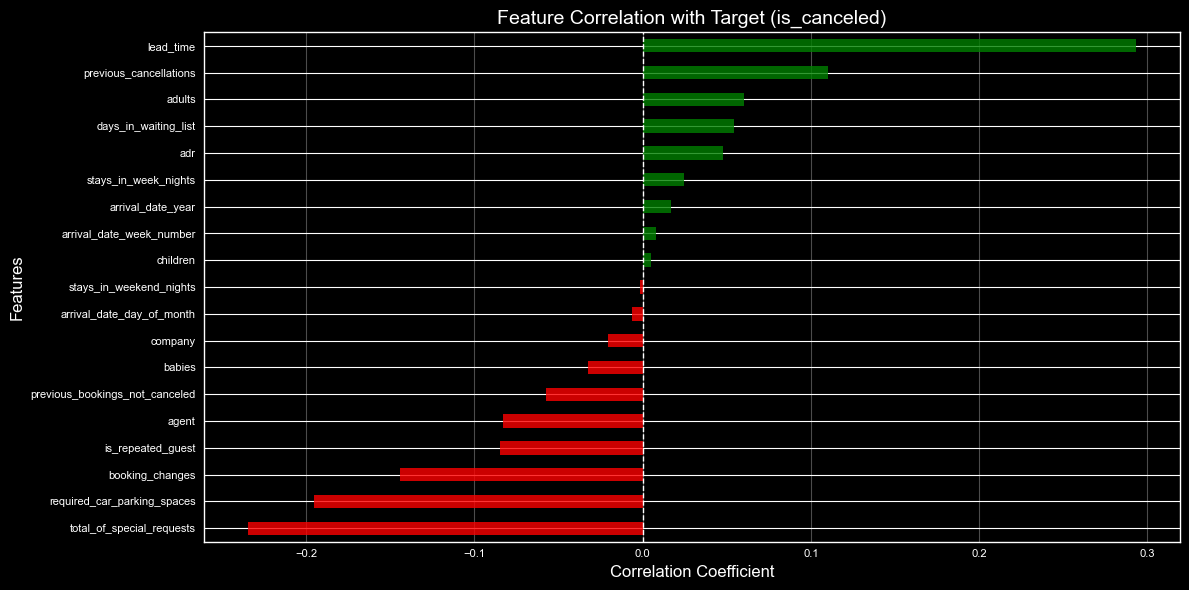

In [155]:
# Target correlation bar plot, see how we can use this plot to visualise correlation values
fig, ax = plt.subplots(figsize=(12, 6))
target_corr = corr_matrix['is_canceled'].drop('is_canceled').sort_values()
colors = ['red' if x < 0 else 'green' for x in target_corr]  # to change that to specific color based on direction of correlation
target_corr.plot(kind='barh', color=colors, ax=ax, alpha=0.8)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Feature Correlation with Target (is_canceled)', fontsize=14)
ax.axvline(0, color='white', linestyle='--', linewidth=1)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Cancellation Rate by Category

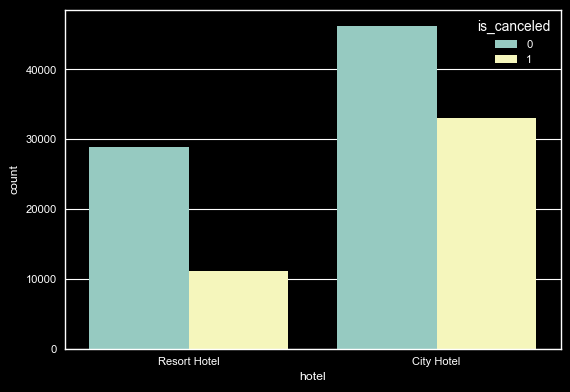

In [156]:
sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled"
)

plt.show()

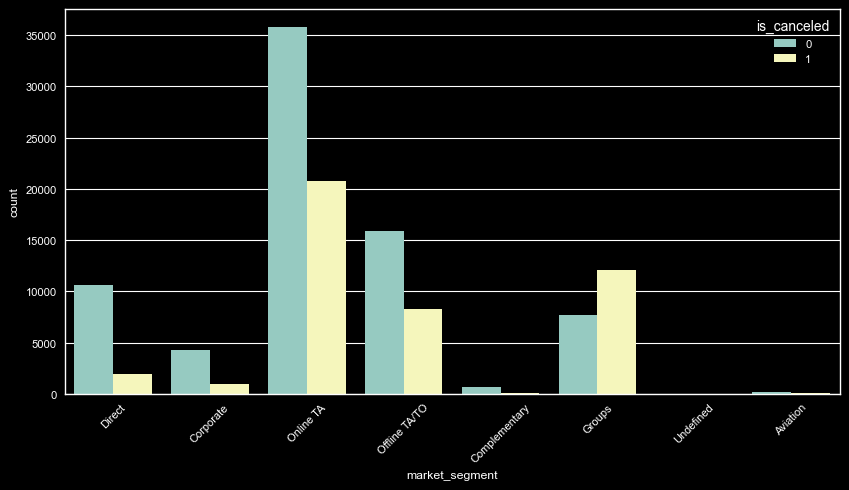

In [157]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="market_segment",
    hue="is_canceled"
)

plt.xticks(rotation=45)

plt.show()

# Box plots for outlier detection

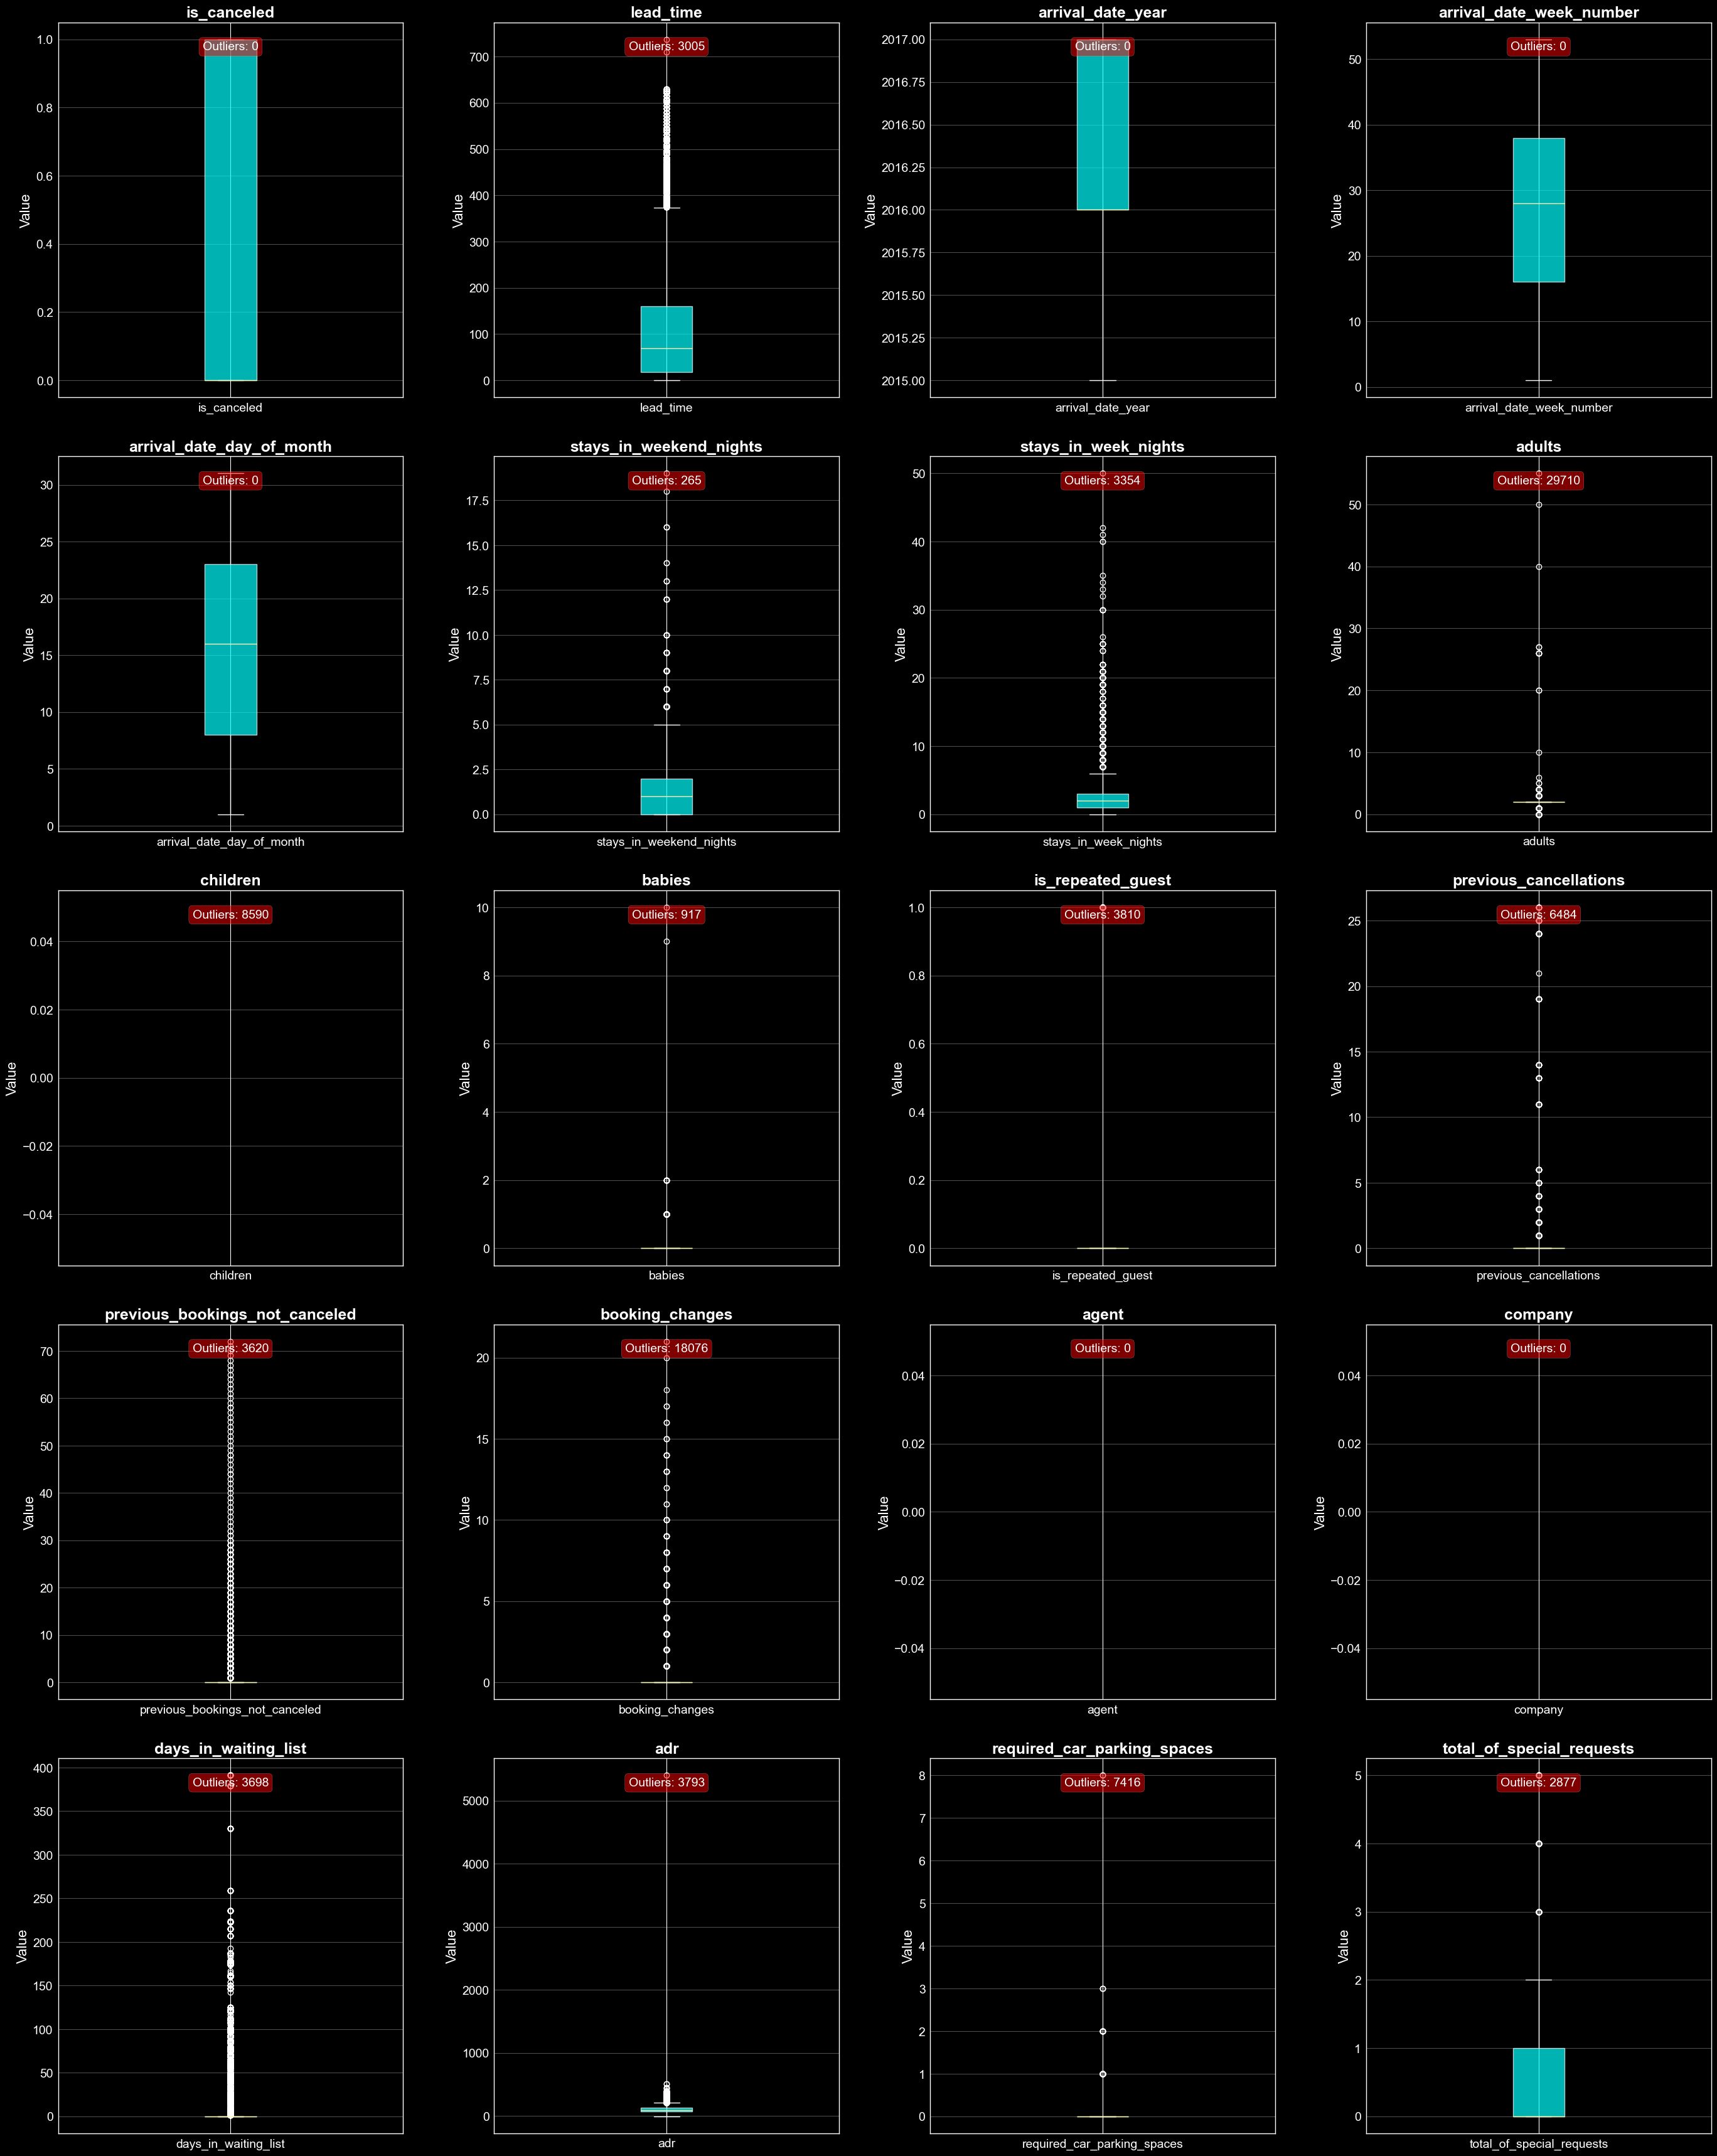

In [158]:
fig, axes = plt.subplots(5, 4, figsize=(28, 35))  
axes = axes.flatten()

for i, col in enumerate(numerical):
    bp = axes[i].boxplot([df[col]], tick_labels=[col], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('cyan')
        patch.set_alpha(0.7)
    axes[i].set_ylabel('Value', fontsize=16)
    axes[i].set_title(f'{col}', fontsize=18, fontweight='bold')
    axes[i].grid(alpha=0.3, axis='y')
    axes[i].tick_params(axis='both', labelsize=14)

    # Count outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].text(0.5, 0.95, f'Outliers: {outliers}',
                 transform=axes[i].transAxes, ha='center', va='top',
                 bbox=dict(boxstyle='round', facecolor='red', alpha=0.5), fontsize=14)

plt.tight_layout(pad=3.0) 
plt.show()

## Insights

## Key Findings

• Company contains the largest number of missing values and was removed during preprocessing.

• The dataset is moderately imbalanced, with non-cancelled bookings being more frequent.

• Lead Time is positively associated with cancellations, indicating that bookings made far in advance are more likely to be canceled.

• Previous cancellations are a strong indicator of future cancellations.

• Deposit Type and Market Segment show noticeable differences between canceled and non-canceled bookings.